# การวิเคราะห์ข้อมูลรายได้และหนี้สินครัวเรือน

Notebook นี้เป็นการสำรวจข้อมูลเบื้องต้นจากสำนักงานสถิติแห่งชาติ (NSO) ระดับจังหวัด เพื่อดูความสัมพันธ์ระหว่างรายได้และหนี้สินครัวเรือน รวมถึงตรวจสอบคุณภาพข้อมูลและสร้างกราฟพื้นฐาน

คำถามหลัก:
- ปริมาณหนี้สินครัวเรือนสัมพันธ์กับรายได้ครัวเรือนหรือไม่ อย่างไร
- กลุ่มสถานะทางเศรษฐสังคมใดมีรายได้และหนี้สินเฉลี่ยสูงที่สุด
- จังหวัดและภูมิภาคใดมีรายได้หรือหนี้สินเฉลี่ยสูงที่สุด

## ขอบเขตและข้อควรระวัง
- ข้อมูลเป็นปี พ.ศ. 2566 (ค.ศ. 2023) เพียงปีเดียว จึงเป็นการเปรียบเทียบแบบ cross-sectional ไม่ใช่แนวโน้มตามเวลา
- ค่ารายได้และค่าใช้จ่ายเป็นค่าเฉลี่ยต่อเดือน ส่วนหนี้สินเป็นหนี้สินเฉลี่ยต่อครัวเรือน หน่วยเป็นบาท
- การหาความสัมพันธ์ใช้ค่าเฉลี่ยระดับจังหวัด 77 จังหวัด ไม่ใช่ข้อมูลรายครัวเรือน และไม่ควรตีความเป็นเหตุเป็นผล
- ไฟล์นี้ไม่มีจำนวนครัวเรือนสำหรับใช้ถ่วงน้ำหนัก ดังนั้นค่าเฉลี่ยระดับภูมิภาคใน notebook คือค่าเฉลี่ยของค่าเฉลี่ยระดับจังหวัด
- ข้อมูลจำแนกตามสถานะทางเศรษฐสังคม ไม่ได้แยกแหล่งที่มาของรายได้หรือวัตถุประสงค์ของหนี้โดยตรง

แหล่งข้อมูล: [data.go.th dataset](https://data.go.th/dataset/0705_08_0031), [NSO CSV resource](https://catalogapi.nso.go.th/api/index?table=SFD_SPB0801&format=csv), [NSO Table 3](https://www.nso.go.th/public/e-book/Analytical-Reports/Income-2566/47/), และ [NSO Table 16](https://www.nso.go.th/public/e-book/Analytical-Reports/Income-2566/94/)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

# Prefer a Thai-capable font when one is available on the machine.
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for candidate in ['Noto Sans Thai', 'Tahoma', 'Arial Unicode MS', 'Th Sarabun New', 'DejaVu Sans']:
    if candidate in available_fonts:
        plt.rcParams['font.family'] = candidate
        break

data_path_candidates = [
    Path('data/raw/SFD_SPB0801.csv'),
    Path('../data/raw/SFD_SPB0801.csv'),
]
data_path = next((path for path in data_path_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find data/raw/SFD_SPB0801.csv. Run this notebook from the repository root.')

raw_df = pd.read_csv(data_path)
metric_column = 'mthincome_mthexp_totaldebt_pctexptoincome'
df = raw_df.rename(columns={metric_column: 'indicator'}).copy()
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df['year_ce'] = df['year'] - 543

TOTAL_LABEL = 'รวมทั้งสิ้น'
print(f'Loaded: {data_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Years (B.E.): {sorted(df["year"].unique().tolist())}')
print(f'Provinces: {df["province"].nunique()}')

Loaded: data/raw/SFD_SPB0801.csv
Shape: 3,388 rows x 10 columns
Years (B.E.): [2566]
Provinces: 77


## 1. ตรวจสอบข้อมูลเบื้องต้นและคุณภาพข้อมูล

In [2]:
print('First five rows:')
print(df.head(5).to_string(index=False))
print()
print('Rows by indicator:')
print(df['indicator'].value_counts().to_string())
print()
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate rows by key fields:', int(df.duplicated(subset=['year', 'province', 'indicator', 'soc_eco_class1', 'soc_eco_class2']).sum()))
print()
print('Missing values by column:')
print(df.isna().sum().sort_values(ascending=False).to_string())
print()
print('Unique units:', df['unit'].unique().tolist())
print('Numeric parsing failures in value:', int(df['value'].isna().sum()))
print('Rows with an attribute note:', int(df['attribute'].notna().sum()))
print('Rows with value equal to zero:', int((df['value'] == 0).sum()))

First five rows:
 year      province              indicator                           soc_eco_class1                                           soc_eco_class2     value unit                                                          attribute                source  year_ce
 2566 กรุงเทพมหานคร รายได้ทั้งสิ้นต่อเดือน                              รวมทั้งสิ้น                                              รวมทั้งสิ้น 40,051.00  บาท                                                                NaN สำนักงานสถิติแห่งชาติ     2023
 2566 กรุงเทพมหานคร รายได้ทั้งสิ้นต่อเดือน          ผู้ถือครองทำการเกษตร/เพาะเลี้ยง ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้าของที่ดิน 29,549.00  บาท                                                                NaN สำนักงานสถิติแห่งชาติ     2023
 2566 กรุงเทพมหานคร รายได้ทั้งสิ้นต่อเดือน          ผู้ถือครองทำการเกษตร/เพาะเลี้ยง  ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ดิน/ทำฟรี      0.00  บาท ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรวจตัวอย่างมีค่าเป็น 

The missing `attribute` values are expected because the field contains notes only for selected observations. The core analysis fields should have no missing values after numeric conversion.

Column types, non-null counts, and cardinality:
                  dtype  non_null  unique_values
year              int64      3388              1
province            str      3388             77
indicator           str      3388              4
soc_eco_class1      str      3388              5
soc_eco_class2      str      3388             11
value           float64      3388           3139
unit                str      3388              2
attribute           str       122              2
source              str      3388              1
year_ce           int64      3388              1

Python value types after numeric conversion:
value
float    3388


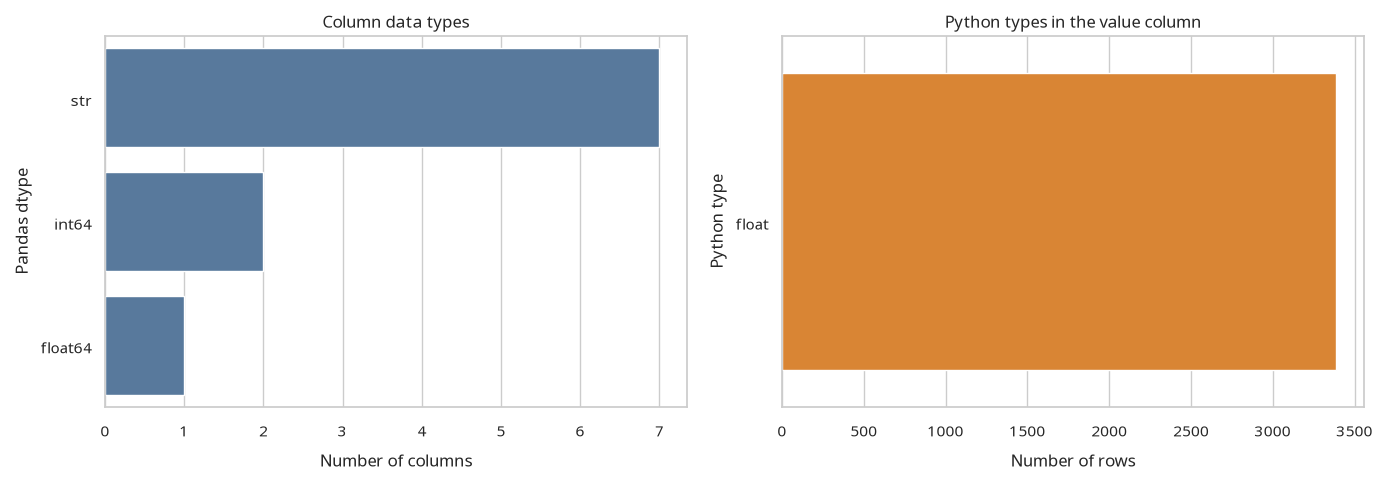

In [3]:
dtype_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'unique_values': df.nunique(dropna=True),
})
print('Column types, non-null counts, and cardinality:')
print(dtype_table.to_string())
print()
value_python_types = df['value'].map(type).map(lambda value_type: value_type.__name__).value_counts()
print('Python value types after numeric conversion:')
print(value_python_types.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dtype_counts = df.dtypes.astype(str).value_counts().rename_axis('dtype').reset_index(name='columns')
sns.barplot(data=dtype_counts, x='columns', y='dtype', ax=axes[0], color='#4C78A8', errorbar=None)
axes[0].set_title('Column data types')
axes[0].set_xlabel('Number of columns')
axes[0].set_ylabel('Pandas dtype')

value_type_plot = value_python_types.rename_axis('python_type').reset_index(name='rows')
sns.barplot(data=value_type_plot, x='rows', y='python_type', ax=axes[1], color='#F58518', errorbar=None)
axes[1].set_title('Python types in the value column')
axes[1].set_xlabel('Number of rows')
axes[1].set_ylabel('Python type')
plt.tight_layout()
plt.show()

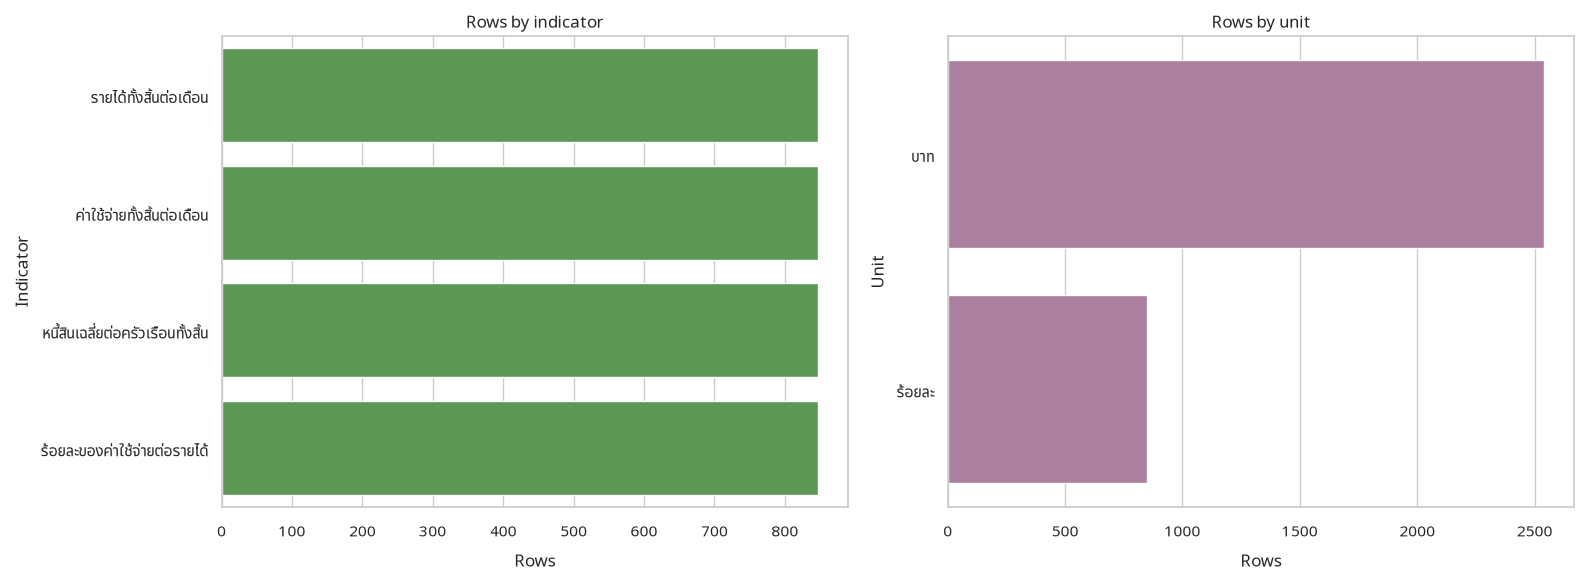

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
indicator_counts = df['indicator'].value_counts().rename_axis('indicator').reset_index(name='rows')
sns.barplot(data=indicator_counts, x='rows', y='indicator', ax=axes[0], color='#54A24B', errorbar=None)
axes[0].set_title('Rows by indicator')
axes[0].set_xlabel('Rows')
axes[0].set_ylabel('Indicator')

unit_counts = df['unit'].value_counts().rename_axis('unit').reset_index(name='rows')
sns.barplot(data=unit_counts, x='rows', y='unit', ax=axes[1], color='#B279A2', errorbar=None)
axes[1].set_title('Rows by unit')
axes[1].set_xlabel('Rows')
axes[1].set_ylabel('Unit')
plt.tight_layout()
plt.show()

## 2. เตรียมชุดข้อมูลระดับจังหวัดและกำหนดภูมิภาค

เพื่อเปรียบเทียบจังหวัดอย่างตรงกัน จะใช้แถวที่ `soc_eco_class1` และ `soc_eco_class2` เป็น `รวมทั้งสิ้น` แล้ว pivot ตัวชี้วัดให้อยู่คนละคอลัมน์

In [5]:
total_scope = df.loc[
    (df['soc_eco_class1'] == TOTAL_LABEL) & (df['soc_eco_class2'] == TOTAL_LABEL)
].copy()

wide = total_scope.pivot(
    index=['year', 'year_ce', 'province'],
    columns='indicator',
    values='value',
).reset_index()
wide.columns.name = None
wide = wide.rename(columns={
    'รายได้ทั้งสิ้นต่อเดือน': 'income_monthly_baht',
    'ค่าใช้จ่ายทั้งสิ้นต่อเดือน': 'expense_monthly_baht',
    'หนี้สินเฉลี่ยต่อครัวเรือนทั้งสิ้น': 'debt_average_baht',
    'ร้อยละของค่าใช้จ่ายต่อรายได้': 'expense_income_pct',
})

REGION_PROVINCES = {
    'กรุงเทพมหานครและ 3 จังหวัด': ['กรุงเทพมหานคร', 'นนทบุรี', 'ปทุมธานี', 'สมุทรปราการ'],
    'ภาคกลาง': [
        'กาญจนบุรี', 'จันทบุรี', 'ฉะเชิงเทรา', 'ชลบุรี', 'ชัยนาท', 'ตราด', 'นครนายก',
        'นครปฐม', 'ประจวบคีรีขันธ์', 'ปราจีนบุรี', 'พระนครศรีอยุธยา', 'เพชรบุรี', 'ระยอง',
        'ราชบุรี', 'ลพบุรี', 'สมุทรสงคราม', 'สมุทรสาคร', 'สระแก้ว', 'สระบุรี', 'สิงห์บุรี',
        'สุพรรณบุรี', 'อ่างทอง',
    ],
    'ภาคเหนือ': [
        'กำแพงเพชร', 'เชียงราย', 'เชียงใหม่', 'ตาก', 'นครสวรรค์', 'น่าน', 'พะเยา',
        'พิจิตร', 'พิษณุโลก', 'เพชรบูรณ์', 'แพร่', 'แม่ฮ่องสอน', 'ลำปาง', 'ลำพูน',
        'สุโขทัย', 'อุตรดิตถ์', 'อุทัยธานี',
    ],
    'ภาคตะวันออกเฉียงเหนือ': [
        'กาฬสินธุ์', 'ขอนแก่น', 'ชัยภูมิ', 'นครพนม', 'นครราชสีมา', 'บึงกาฬ', 'บุรีรัมย์',
        'มหาสารคาม', 'มุกดาหาร', 'ยโสธร', 'ร้อยเอ็ด', 'เลย', 'ศรีสะเกษ', 'สกลนคร',
        'สุรินทร์', 'หนองคาย', 'หนองบัวลำภู', 'อุดรธานี', 'อุบลราชธานี', 'อำนาจเจริญ',
    ],
    'ภาคใต้': [
        'กระบี่', 'ชุมพร', 'ตรัง', 'นครศรีธรรมราช', 'นราธิวาส', 'ปัตตานี', 'พังงา',
        'พัทลุง', 'ภูเก็ต', 'ยะลา', 'ระนอง', 'สงขลา', 'สตูล', 'สุราษฎร์ธานี',
    ],
}

province_to_region = {
    province: region
    for region, provinces in REGION_PROVINCES.items()
    for province in provinces
}
wide['region'] = wide['province'].map(province_to_region)
wide['region'] = pd.Categorical(wide['region'], categories=list(REGION_PROVINCES), ordered=True)

required_metrics = ['income_monthly_baht', 'expense_monthly_baht', 'debt_average_baht', 'expense_income_pct']
assert len(total_scope) == 77 * 4
assert wide['province'].nunique() == 77
assert wide[required_metrics].notna().all().all()
assert wide['region'].notna().all()
print(f'Total-scope rows: {len(total_scope):,}')
print(f'Province-level rows after pivot: {len(wide):,}')
print('Province counts by region:')
print(wide.groupby('region', observed=True)['province'].nunique().to_string())

Total-scope rows: 308
Province-level rows after pivot: 77
Province counts by region:
region
กรุงเทพมหานครและ 3 จังหวัด     4
ภาคกลาง                       22
ภาคเหนือ                      17
ภาคตะวันออกเฉียงเหนือ         20
ภาคใต้                        14


## 3. จังหวัดและภูมิภาคที่มีรายได้หรือหนี้สินสูงที่สุด

Top 10 provinces by average household debt:
  province                     region  income_monthly_baht  debt_average_baht  expense_income_pct
    ภูเก็ต                     ภาคใต้            41,865.00         424,977.00               93.02
  ปทุมธานี กรุงเทพมหานครและ 3 จังหวัด            45,729.00         362,493.00               78.73
อำนาจเจริญ      ภาคตะวันออกเฉียงเหนือ            28,515.00         337,610.00               79.61
   ราชบุรี                    ภาคกลาง            31,368.00         314,967.00               84.28
    กระบี่                     ภาคใต้            28,360.00         314,717.00               86.52
 เพชรบูรณ์                   ภาคเหนือ            27,717.00         309,224.00               75.43
นครราชสีมา      ภาคตะวันออกเฉียงเหนือ            27,775.00         303,257.00               77.77
  สุรินทร์      ภาคตะวันออกเฉียงเหนือ            22,216.00         290,152.00               82.29
  มุกดาหาร      ภาคตะวันออกเฉียงเหนือ            24,925.00         285,176

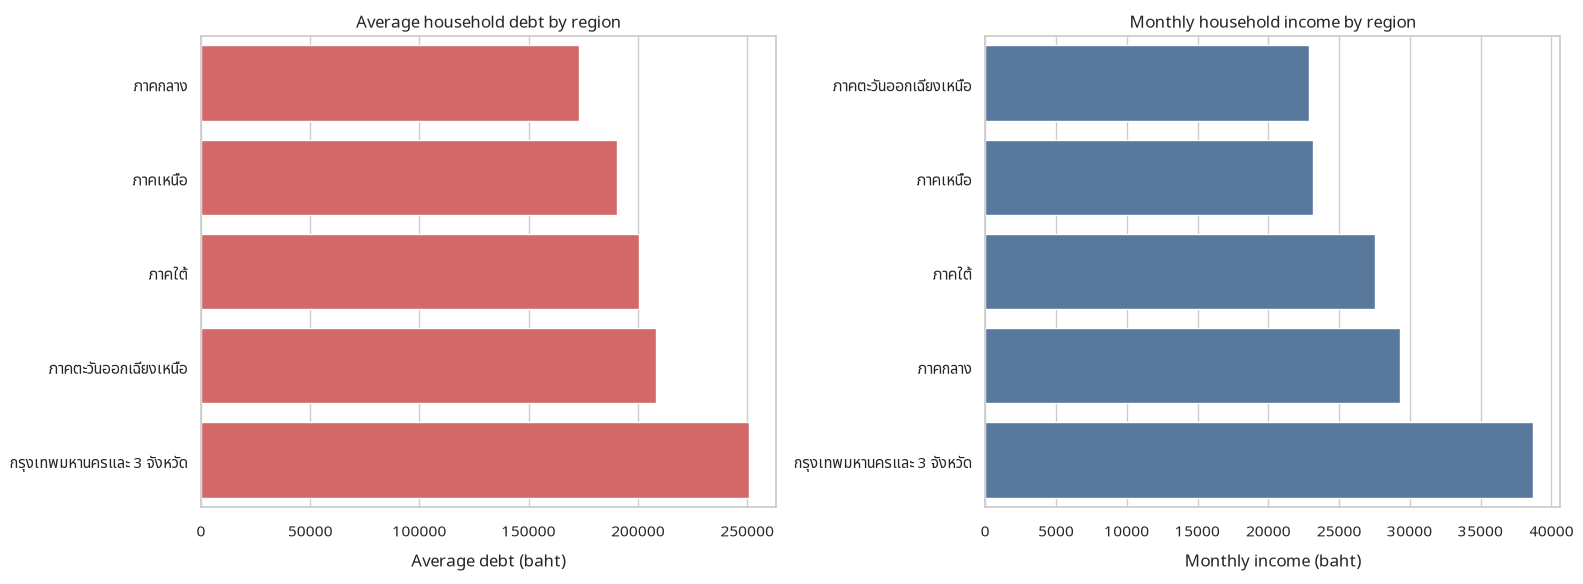

In [6]:
province_display_cols = ['province', 'region', 'income_monthly_baht', 'debt_average_baht', 'expense_income_pct']
print('Top 10 provinces by average household debt:')
print(wide.nlargest(10, 'debt_average_baht')[province_display_cols].to_string(index=False))
print()
print('Top 10 provinces by monthly total household income:')
print(wide.nlargest(10, 'income_monthly_baht')[province_display_cols].to_string(index=False))

region_summary = (
    wide.groupby('region', observed=True)
    .agg(
        provinces=('province', 'nunique'),
        income_monthly_baht=('income_monthly_baht', 'mean'),
        debt_average_baht=('debt_average_baht', 'mean'),
        expense_income_pct=('expense_income_pct', 'mean'),
    )
    .sort_values('debt_average_baht', ascending=False)
)
print()
print('Regional summary (simple mean of provincial averages):')
print(region_summary.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
debt_region_order = region_summary.sort_values('debt_average_baht').index
income_region_order = region_summary.sort_values('income_monthly_baht').index
region_plot = region_summary.reset_index()
sns.barplot(data=region_plot, x='debt_average_baht', y='region', order=debt_region_order, ax=axes[0], color='#E45756', errorbar=None)
axes[0].set_title('Average household debt by region')
axes[0].set_xlabel('Average debt (baht)')
axes[0].set_ylabel('')
sns.barplot(data=region_plot, x='income_monthly_baht', y='region', order=income_region_order, ax=axes[1], color='#4C78A8', errorbar=None)
axes[1].set_title('Monthly household income by region')
axes[1].set_xlabel('Monthly income (baht)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 4. ความสัมพันธ์ระหว่างรายได้กับหนี้สิน

การคำนวณต่อไปนี้เป็นความสัมพันธ์ระหว่างค่าเฉลี่ยระดับจังหวัด จึงตอบได้เพียงว่าในปี 2566 จังหวัดที่มีรายได้เฉลี่ยสูงกว่ามักมีหนี้สินเฉลี่ยสูงกว่าหรือไม่ ไม่ได้พิสูจน์ว่ารายได้เป็นสาเหตุของหนี้สิน

Pearson correlation (n=77 provinces): 0.488
Spearman rank correlation: 0.389
Mean monthly income: 26,445 baht
Mean average debt: 195,125 baht


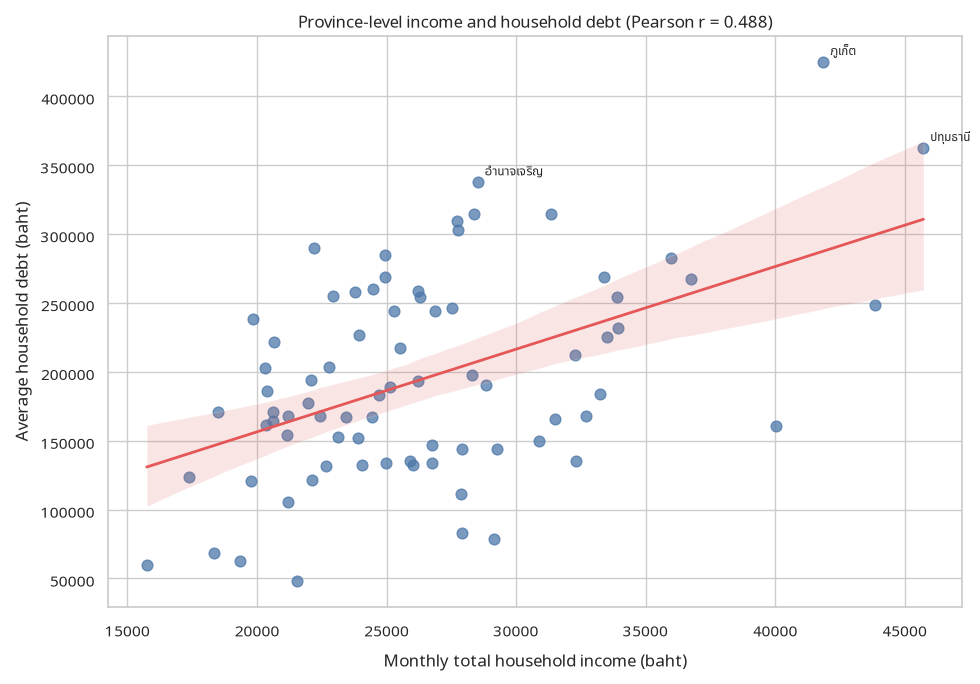

In [7]:
relationship_cols = ['income_monthly_baht', 'debt_average_baht']
pearson_r = wide[relationship_cols].corr(method='pearson').iloc[0, 1]
spearman_r = wide[relationship_cols].corr(method='spearman').iloc[0, 1]
print(f'Pearson correlation (n={len(wide)} provinces): {pearson_r:.3f}')
print(f'Spearman rank correlation: {spearman_r:.3f}')
print(f'Mean monthly income: {wide["income_monthly_baht"].mean():,.0f} baht')
print(f'Mean average debt: {wide["debt_average_baht"].mean():,.0f} baht')

fig, ax = plt.subplots(figsize=(10, 7))
sns.regplot(
    data=wide,
    x='income_monthly_baht',
    y='debt_average_baht',
    ax=ax,
    scatter_kws={'s': 60, 'alpha': 0.75, 'color': '#4C78A8'},
    line_kws={'color': '#E45756', 'linewidth': 2},
)
for _, row in wide.nlargest(3, 'debt_average_baht').iterrows():
    ax.annotate(row['province'], (row['income_monthly_baht'], row['debt_average_baht']), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_title(f'Province-level income and household debt (Pearson r = {pearson_r:.3f})')
ax.set_xlabel('Monthly total household income (baht)')
ax.set_ylabel('Average household debt (baht)')
plt.tight_layout()
plt.show()

## 5. กลุ่มสถานะทางเศรษฐสังคมที่มีค่าเฉลี่ยรายได้และหนี้สินสูง

ส่วนนี้ใช้ `soc_eco_class2` ซึ่งเป็นหมวดหมู่ย่อยที่ละเอียดกว่า โดยเฉลี่ยค่าของจังหวัดที่มีข้อมูลในแต่ละหมวดหมู่ การจัดอันดับนี้เป็นการจัดอันดับของ **ค่าเฉลี่ยต่อครัวเรือนในหมวดหมู่** ไม่ใช่ส่วนแบ่งของรายได้หรือหนี้สินรวมทั้งประเทศ

Top detailed socioeconomic groups by average monthly income:
                          soc_eco_class1                                           soc_eco_class2  income_monthly_baht  debt_average_baht
                                 ลูกจ้าง               ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ            48,292.91         558,901.04
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร                 ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร            33,298.61         264,960.21
         ผู้ถือครองทำการเกษตร/เพาะเลี้ยง ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้าของที่ดิน            27,264.10         187,962.10
                                 ลูกจ้าง                             เสมียนพนักงานขายและให้บริการ            25,684.36         180,260.87
         ผู้ถือครองทำการเกษตร/เพาะเลี้ยง  ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ดิน/ทำฟรี            24,063.81         239,350.51

Top detailed socioeconomic groups by average household debt:
                          soc_eco_class1         

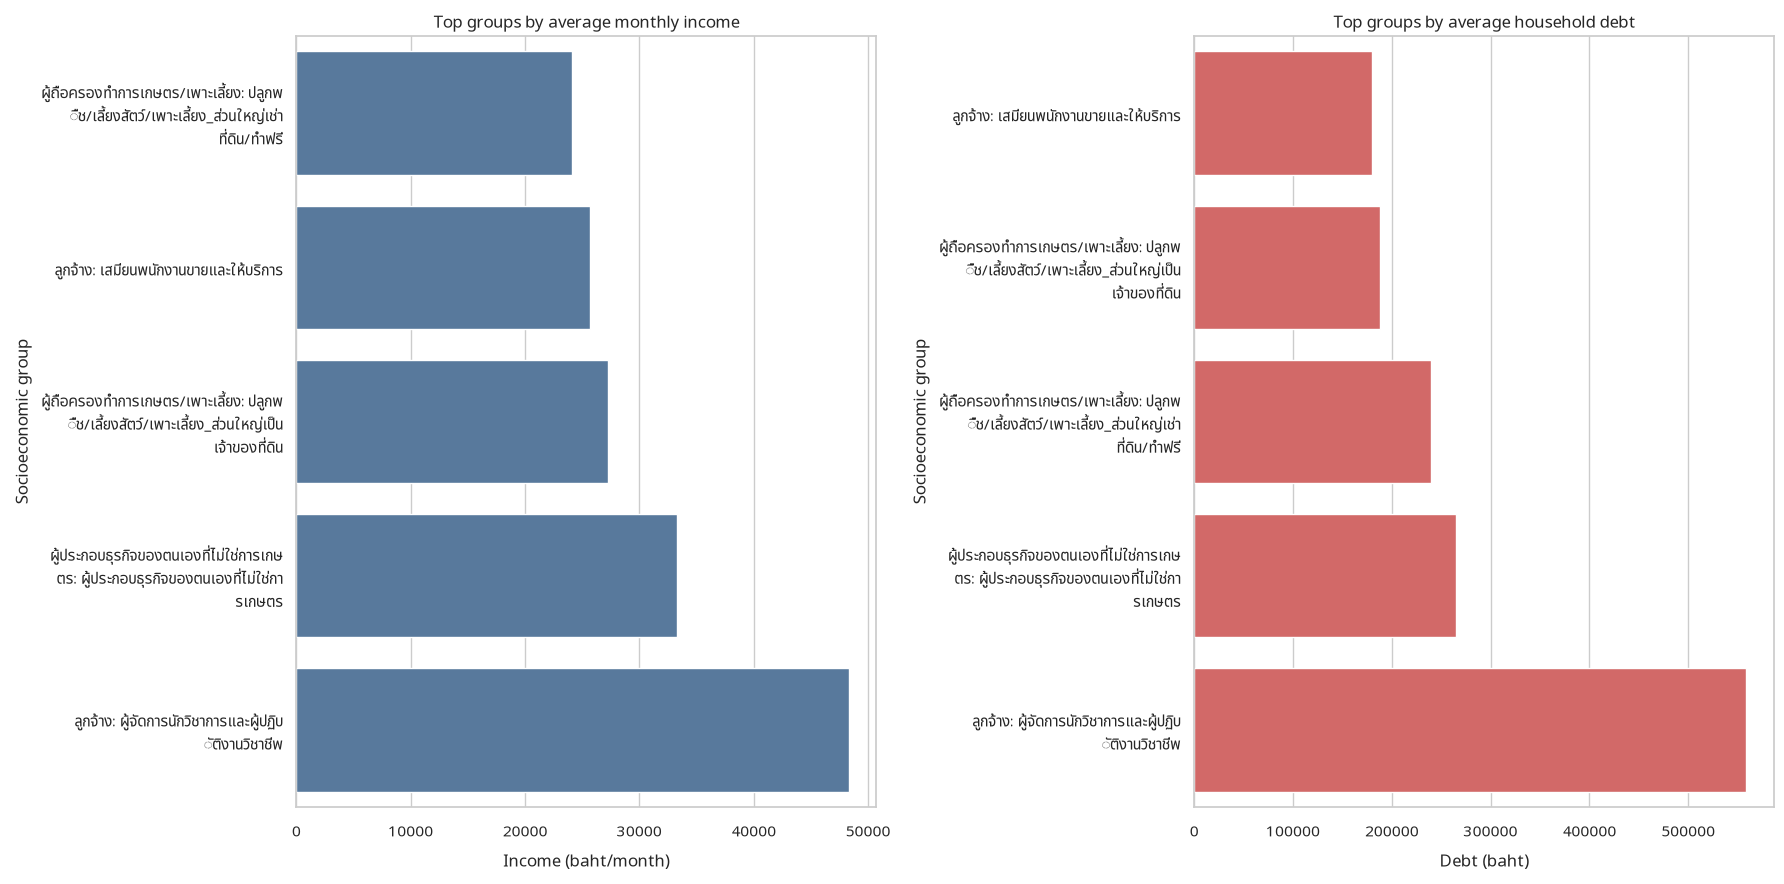

In [8]:
detail = (
    df.loc[df['soc_eco_class2'] != TOTAL_LABEL]
    .pivot_table(
        index=['province', 'soc_eco_class1', 'soc_eco_class2'],
        columns='indicator',
        values='value',
        aggfunc='first',
    )
    .reset_index()
)
detail.columns.name = None
detail = detail.rename(columns={
    'รายได้ทั้งสิ้นต่อเดือน': 'income_monthly_baht',
    'หนี้สินเฉลี่ยต่อครัวเรือนทั้งสิ้น': 'debt_average_baht',
})

class_summary = (
    detail.groupby(['soc_eco_class1', 'soc_eco_class2'], observed=True)[['income_monthly_baht', 'debt_average_baht']]
    .mean()
    .reset_index()
)
class_summary['category_label'] = class_summary['soc_eco_class1'] + ': ' + class_summary['soc_eco_class2']
class_summary['category_label'] = class_summary['category_label'].map(lambda label: __import__('textwrap').fill(str(label), width=38))

income_top = class_summary.nlargest(5, 'income_monthly_baht')
debt_top = class_summary.nlargest(5, 'debt_average_baht')
print('Top detailed socioeconomic groups by average monthly income:')
print(income_top[['soc_eco_class1', 'soc_eco_class2', 'income_monthly_baht', 'debt_average_baht']].round(2).to_string(index=False))
print()
print('Top detailed socioeconomic groups by average household debt:')
print(debt_top[['soc_eco_class1', 'soc_eco_class2', 'income_monthly_baht', 'debt_average_baht']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
sns.barplot(data=income_top.sort_values('income_monthly_baht'), x='income_monthly_baht', y='category_label', ax=axes[0], color='#4C78A8', errorbar=None)
axes[0].set_title('Top groups by average monthly income')
axes[0].set_xlabel('Income (baht/month)')
axes[0].set_ylabel('Socioeconomic group')
sns.barplot(data=debt_top.sort_values('debt_average_baht'), x='debt_average_baht', y='category_label', ax=axes[1], color='#E45756', errorbar=None)
axes[1].set_title('Top groups by average household debt')
axes[1].set_xlabel('Debt (baht)')
axes[1].set_ylabel('Socioeconomic group')
plt.tight_layout()
plt.show()

## สรุปผลเบื้องต้น

ผลลัพธ์ในเซลล์ด้านบนจะช่วยตอบคำถามในขอบเขตของชุดข้อมูลนี้ โดยควรอ่านร่วมกับข้อจำกัดของข้อมูล: ไม่มีข้อมูลรายได้/หนี้รายครัวเรือน ไม่มีจำนวนครัวเรือนสำหรับถ่วงน้ำหนักในไฟล์ CSV และไม่มีข้อมูลหลายปีสำหรับวิเคราะห์แนวโน้ม หากต้องการตอบว่าเงินกู้มาจากอะไรหรือหนี้มีวัตถุประสงค์ใด ควรเสริมชุดข้อมูลสำรวจที่มีตัวแปรประเภทแหล่งรายได้และวัตถุประสงค์การกู้ยืม

In [9]:
highest_debt = wide.loc[wide['debt_average_baht'].idxmax()]
highest_income = wide.loc[wide['income_monthly_baht'].idxmax()]
highest_debt_region = region_summary['debt_average_baht'].idxmax()
highest_income_region = region_summary['income_monthly_baht'].idxmax()
top_income_group = class_summary.loc[class_summary['income_monthly_baht'].idxmax()]
top_debt_group = class_summary.loc[class_summary['debt_average_baht'].idxmax()]

print('Key findings for the total provincial scope:')
print(f'- Highest-debt province: {highest_debt["province"]} ({highest_debt["debt_average_baht"]:,.0f} baht)')
print(f'- Highest-income province: {highest_income["province"]} ({highest_income["income_monthly_baht"]:,.0f} baht/month)')
print(f'- Highest-debt region by mean provincial average: {highest_debt_region}')
print(f'- Highest-income region by mean provincial average: {highest_income_region}')
print(f'- Highest-income detailed socioeconomic group: {top_income_group["soc_eco_class2"]}')
print(f'- Highest-debt detailed socioeconomic group: {top_debt_group["soc_eco_class2"]}')
print(f'- Province-level Pearson correlation: {pearson_r:.3f}')

Key findings for the total provincial scope:
- Highest-debt province: ภูเก็ต (424,977 baht)
- Highest-income province: ปทุมธานี (45,729 baht/month)
- Highest-debt region by mean provincial average: กรุงเทพมหานครและ 3 จังหวัด
- Highest-income region by mean provincial average: กรุงเทพมหานครและ 3 จังหวัด
- Highest-income detailed socioeconomic group: ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ
- Highest-debt detailed socioeconomic group: ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ
- Province-level Pearson correlation: 0.488


## 6. ตรวจสอบชุดข้อมูลเสริมจาก NSO ในปีเดียวกัน

ชุดข้อมูลเสริมต่อไปนี้ดาวน์โหลดจาก NSO Catalog API และเก็บเฉพาะปี พ.ศ. 2566 เพื่อให้ตรงกับ SFD_SPB0801 เดิม:

- SFD_SPB0802_66: รายได้จำแนกตามแหล่งที่มา ระดับจังหวัด
- SFD_SPB0806 และ SFD_SPB0807: หนี้สินเฉลี่ยระดับจังหวัด ทั้งครัวเรือนและเฉพาะครัวเรือนที่เป็นหนี้
- SES_OS_29 ถึง SES_OS_31: จำนวนครัวเรือนที่เป็นหนี้ แหล่งเงินกู้ และประเภทหนี้ ระดับภูมิภาค/เขตการปกครอง
- SES_41_01 ถึง SES_41_05: รายได้ การกระจายรายได้ และ quintile ระดับภูมิภาค/สถานะทางเศรษฐสังคม

สามไฟล์ SFD เป็นระดับจังหวัดและใช้ตรวจสอบร่วมกับฐานเดิมได้ ส่วนไฟล์ SES เป็นระดับภูมิภาคหรือเขตการปกครอง จึงใช้เปรียบเทียบแยกชุด ไม่ควร merge กับจังหวัดโดยตรง.

In [10]:
supplementary_dir_candidates = [Path('data/raw'), Path('../data/raw')]
supplementary_dir = next((path for path in supplementary_dir_candidates if path.exists()), None)
if supplementary_dir is None:
    raise FileNotFoundError('Could not find supplementary CSV snapshots in data/raw.')

supplementary_files = {
    'income_source_province': 'SFD_SPB0802_66.csv',
    'debt_all_households_province': 'SFD_SPB0806.csv',
    'debt_indebted_households_province': 'SFD_SPB0807.csv',
    'indebted_count_region': 'SES_OS_29_2566.csv',
    'indebted_source_purpose_region': 'SES_OS_30_2566.csv',
    'indebted_type_region': 'SES_OS_31_2566.csv',
    'income_source_region': 'SES_41_01_2566.csv',
    'income_socioeconomic': 'SES_41_02_2566.csv',
    'income_distribution_region': 'SES_41_03_2566.csv',
    'income_distribution_socioeconomic': 'SES_41_04_2566.csv',
    'income_quintile_region': 'SES_41_05_2566.csv',
}
supplementary_data = {
    name: pd.read_csv(supplementary_dir / filename)
    for name, filename in supplementary_files.items()
}


def year_column(frame):
    return next(column for column in ['year', 'Year', 'YEAR'] if column in frame.columns)


inventory_rows = []
for name, frame in supplementary_data.items():
    year_col = year_column(frame)
    geography = 'province' if 'province' in frame.columns else 'region/area'
    inventory_rows.append({
        'dataset': name,
        'file': supplementary_files[name],
        'rows': len(frame),
        'columns': len(frame.columns),
        'years': sorted(frame[year_col].dropna().unique().tolist()),
        'geography': geography,
        'duplicate_rows': int(frame.duplicated().sum()),
    })

inventory = pd.DataFrame(inventory_rows)
print('Supplementary-data inventory:')
print(inventory.to_string(index=False))
print()
print('Sample rows from the principal new tables:')
for name in [
    'income_source_province',
    'debt_all_households_province',
    'debt_indebted_households_province',
    'indebted_source_purpose_region',
    'income_source_region',
]:
    print(f'\n{name}:')
    print(supplementary_data[name].head(2).to_string(index=False))

for frame in supplementary_data.values():
    assert set(frame[year_column(frame)].dropna().unique()) == {2566}

province_set = set(df['province'])
for name in [
    'income_source_province',
    'debt_all_households_province',
    'debt_indebted_households_province',
]:
    assert set(supplementary_data[name]['province']) == province_set

print('All stored supplementary snapshots contain only B.E. 2566 rows.')
print('All three provincial snapshots contain the same 77 provinces as SFD_SPB0801.')

Supplementary-data inventory:
                          dataset               file  rows  columns  years   geography  duplicate_rows
           income_source_province SFD_SPB0802_66.csv  7700       11 [2566]    province               0
     debt_all_households_province    SFD_SPB0806.csv  7700       11 [2566]    province               0
debt_indebted_households_province    SFD_SPB0807.csv  7700       11 [2566]    province               0
            indebted_count_region SES_OS_29_2566.csv    18        6 [2566] region/area               0
   indebted_source_purpose_region SES_OS_30_2566.csv   234        8 [2566] region/area               0
             indebted_type_region SES_OS_31_2566.csv    72        7 [2566] region/area               0
             income_source_region SES_41_01_2566.csv    18       15 [2566] region/area               0
             income_socioeconomic SES_41_02_2566.csv    11       13 [2566] region/area               0
       income_distribution_region SES_41_03

In [11]:
# Cross-check overlapping indicators against the original SFD_SPB0801 snapshot.
comparison_key = ['province', 'soc_eco_class1', 'soc_eco_class2']

current_income = (
    df.loc[
        (df['indicator'] == 'รายได้ทั้งสิ้นต่อเดือน')
        & (df['soc_eco_class1'] != TOTAL_LABEL),
        comparison_key + ['value'],
    ]
    .rename(columns={'value': 'current_value'})
)
source_income_total = (
    supplementary_data['income_source_province']
    .loc[
        supplementary_data['income_source_province']['source_income3'] == 'รายได้ทั้งสิ้นต่อเดือน',
        comparison_key + ['value'],
    ]
    .rename(columns={'value': 'source_value'})
)
income_comparison = current_income.merge(source_income_total, on=comparison_key, how='outer', indicator=True)
income_comparison['absolute_difference'] = (
    income_comparison['current_value'] - income_comparison['source_value']
).abs()
income_mismatches = income_comparison.loc[income_comparison['absolute_difference'] > 0]

current_debt = (
    df.loc[
        (df['indicator'] == 'หนี้สินเฉลี่ยต่อครัวเรือนทั้งสิ้น')
        & (df['soc_eco_class1'] != TOTAL_LABEL),
        comparison_key + ['value'],
    ]
    .rename(columns={'value': 'current_value'})
)
source_debt_total = (
    supplementary_data['debt_all_households_province']
    .loc[
        supplementary_data['debt_all_households_province']['purpose_source_bor']
        == 'จำนวนหนี้สินเฉลี่ยต่อครัวเรือน',
        comparison_key + ['value'],
    ]
    .rename(columns={'value': 'source_value'})
)
debt_comparison = current_debt.merge(source_debt_total, on=comparison_key, how='outer', indicator=True)
debt_comparison['absolute_difference'] = (
    debt_comparison['current_value'] - debt_comparison['source_value']
).abs()
debt_mismatches = debt_comparison.loc[debt_comparison['absolute_difference'] > 0]

print(f'Income overlapping keys: {len(income_comparison):,}; unmatched: {(income_comparison["_merge"] != "both").sum()}')
print(f'Income exact matches: {len(income_comparison) - len(income_mismatches):,}; mismatches: {len(income_mismatches):,}')
if not income_mismatches.empty:
    print('Income mismatch(es) retained as published by each source snapshot:')
    print(income_mismatches.to_string(index=False))
print(f'Debt overlapping keys: {len(debt_comparison):,}; unmatched: {(debt_comparison["_merge"] != "both").sum()}')
print(f'Debt exact matches: {len(debt_comparison) - len(debt_mismatches):,}; mismatches: {len(debt_mismatches):,}')
assert len(income_comparison) == 770
assert len(debt_comparison) == 770
assert len(debt_mismatches) == 0

negative_income_rows = supplementary_data['income_source_province'].loc[
    supplementary_data['income_source_province']['value'] < 0
]
print(f'Negative values in provincial income-source table: {len(negative_income_rows):,}')
print('Negative values are retained because some source fields represent net agricultural/business profit; inspect before treating them as errors.')

Income overlapping keys: 770; unmatched: 0
Income exact matches: 769; mismatches: 1
Income mismatch(es) retained as published by each source snapshot:
 province                  soc_eco_class1                                          soc_eco_class2  current_value  source_value _merge  absolute_difference
สมุทรสาคร ผู้ถือครองทำการเกษตร/เพาะเลี้ยง ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ดิน/ทำฟรี         600.00       -600.00   both             1,200.00
Debt overlapping keys: 770; unmatched: 0
Debt exact matches: 770; mismatches: 0
Negative values in provincial income-source table: 36
Negative values are retained because some source fields represent net agricultural/business profit; inspect before treating them as errors.


### แหล่งที่มาของรายได้ในปี 2566

ตาราง SES_41_01 มีรายได้ระดับภูมิภาคและระดับเขตการปกครอง โดยใช้แถวประเทศไทยรวมเพื่อดูองค์ประกอบรายได้โดยไม่เฉลี่ยซ้ำข้ามกลุ่มเศรษฐสังคม.

Thailand monthly household income: 29,030 baht
Income components:
                              baht_per_month  share_of_monthly_income_pct
รายได้จากการทำงาน                  20,465.00                        70.50
รายได้ไม่เป็นตัวเงิน                4,205.00                        14.49
เงินโอน/เงินช่วยเหลือ               3,794.00                        13.07
รายได้ไม่ประจำที่เป็นตัวเงิน          325.00                         1.12
รายได้จากทรัพย์สิน                    242.00                         0.83
Largest component: รายได้จากการทำงาน (20,465 baht/month)


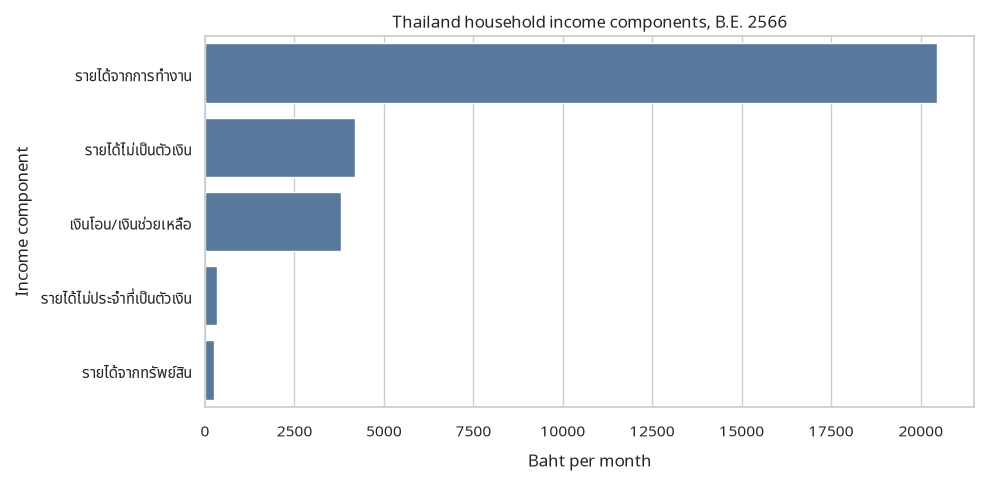

In [12]:
income_region = supplementary_data['income_source_region'].copy()
national_income = income_region.loc[
    (income_region['REGION'] == 'ทั่วราชอาณาจักร')
    & (income_region['AREA'] == 'เขตการปกครอง')
].iloc[0]

income_component_labels = {
    'รายได้จากการทำงาน': 'FROM_WORK',
    'เงินโอน/เงินช่วยเหลือ': 'CURRENT_TRANSFER',
    'รายได้จากทรัพย์สิน': 'PROPERTY_INCOME',
    'รายได้ไม่เป็นตัวเงิน': 'NONMONEY_INCOME',
    'รายได้ไม่ประจำที่เป็นตัวเงิน': 'NONCUR_M_INCOME',
}
income_components = pd.Series(
    {label: float(national_income[column]) for label, column in income_component_labels.items()},
    name='baht_per_month',
).sort_values(ascending=False)
income_components_table = income_components.to_frame()
income_components_table['share_of_monthly_income_pct'] = (
    income_components / float(national_income['MONTHLY_INCOME']) * 100
)
print(f"Thailand monthly household income: {national_income['MONTHLY_INCOME']:,.0f} baht")
print('Income components:')
print(income_components_table.round(2).to_string())
print(f"Largest component: {income_components.index[0]} ({income_components.iloc[0]:,.0f} baht/month)")

fig, ax = plt.subplots(figsize=(10, 5))
income_plot = income_components.rename_axis('component').reset_index()
sns.barplot(data=income_plot, x='baht_per_month', y='component', ax=ax, color='#4C78A8', errorbar=None)
ax.set_title('Thailand household income components, B.E. 2566')
ax.set_xlabel('Baht per month')
ax.set_ylabel('Income component')
plt.tight_layout()
plt.show()

### จำนวนครัวเรือนที่เป็นหนี้ แหล่งเงินกู้ และวัตถุประสงค์

SES_OS_29 ถึง SES_OS_31 เป็นจำนวนครัวเรือน ไม่ใช่ยอดหนี้ จึงใช้ตอบว่าหนี้กระจุกตัวที่วัตถุประสงค์หรือประเภทใด โดยเลือกข้อมูลประเทศไทยรวม.

Indebted households in Thailand: 11,472,172 households
Indebted households by loan source and borrowing purpose:
Source_loan                       Purpose_borrow   value
 หนี้ในระบบ ใช้จ่ายอุปโภคบริโภคอื่นๆ ในครัวเรือน 7728981
 หนี้ในระบบ                   ใช้ในการทำการเกษตร 2786637
 หนี้ในระบบ   ใช้ซื้อ/เช่าซื้อบ้านและ/หรือที่ดิน 1638465
 หนี้ในระบบ                     ใช้ในการทำธุรกิจ  933037
หนี้นอกระบบ ใช้จ่ายอุปโภคบริโภคอื่นๆ ในครัวเรือน  613890
 หนี้ในระบบ                        ใช้ในการศึกษา  417894
หนี้นอกระบบ                     ใช้ในการทำธุรกิจ  131782
หนี้นอกระบบ                   ใช้ในการทำการเกษตร   69740
 หนี้ในระบบ                                อื่นๆ   53400
หนี้นอกระบบ   ใช้ซื้อ/เช่าซื้อบ้านและ/หรือที่ดิน   30994
หนี้นอกระบบ                        ใช้ในการศึกษา   19162
หนี้นอกระบบ                                อื่นๆ   12419

Indebted households by debt type:
              Type_debt    value
 มีหนี้ในระบบอย่างเดียว 10613594
มีหนี้นอกระบบอย่างเดียว   548804
 มีหนี้ทั้งใ

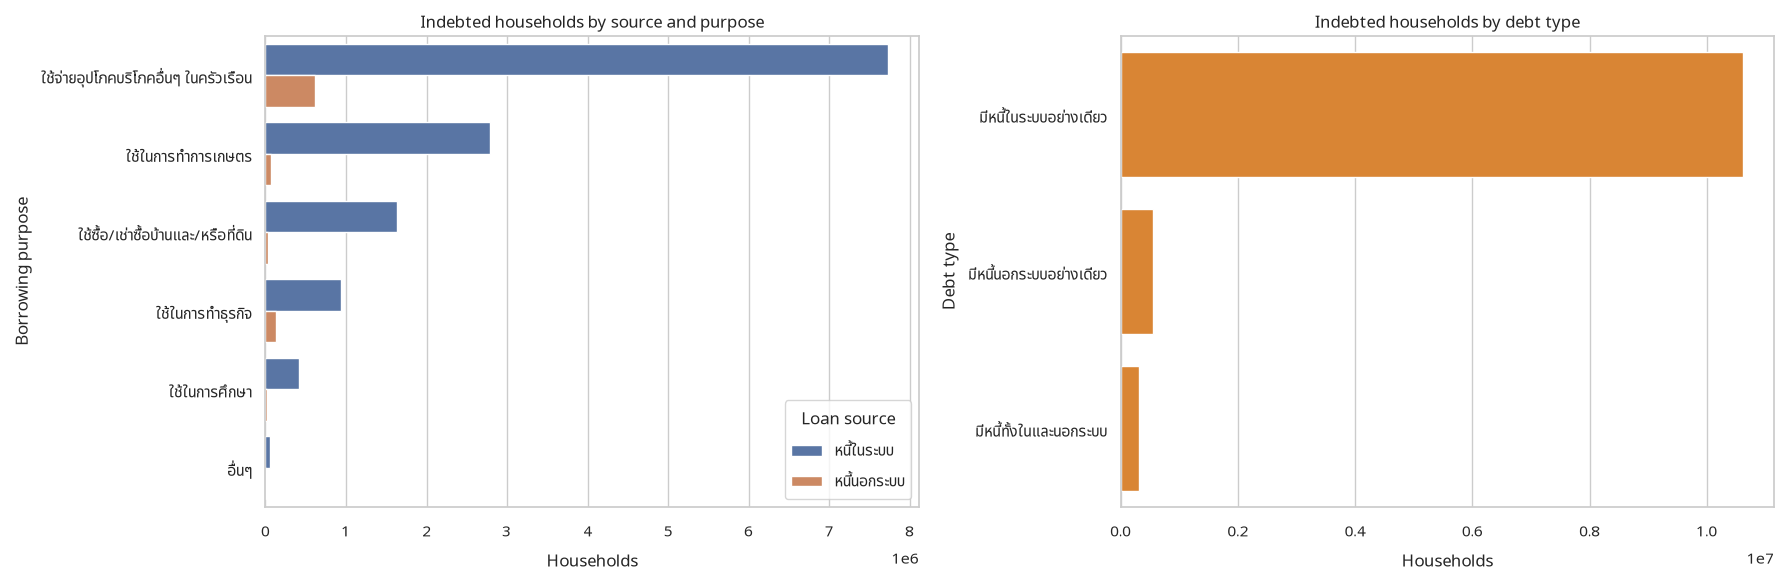

In [13]:
debt_count_region = supplementary_data['indebted_count_region'].copy()
debt_source_purpose_region = supplementary_data['indebted_source_purpose_region'].copy()
debt_type_region = supplementary_data['indebted_type_region'].copy()

for frame, columns in [
    (debt_count_region, ['Region', 'Area']),
    (debt_source_purpose_region, ['Region', 'Area', 'Source_loan', 'Purpose_borrow']),
    (debt_type_region, ['Region', 'Area', 'Type_debt']),
]:
    for column in columns:
        frame[column] = frame[column].astype(str).str.strip()

national_indebted_count = debt_count_region.loc[
    (debt_count_region['Region'] == 'ทั่วราชอาณาจักร')
    & (debt_count_region['Area'] == 'รวม'),
    'value',
].iloc[0]

purpose_by_source = debt_source_purpose_region.loc[
    (debt_source_purpose_region['Region'] == 'ทั่วราชอาณาจักร')
    & (debt_source_purpose_region['Area'] == 'รวม')
    & (debt_source_purpose_region['Source_loan'] != 'รวม')
    & (debt_source_purpose_region['Purpose_borrow'] != 'รวม'),
    ['Source_loan', 'Purpose_borrow', 'value'],
].sort_values('value', ascending=False)

type_national = debt_type_region.loc[
    (debt_type_region['Region'] == 'ทั่วราชอาณาจักร')
    & (debt_type_region['Area'] == 'รวม')
    & (debt_type_region['Type_debt'] != 'รวม'),
    ['Type_debt', 'value'],
].sort_values('value', ascending=False)

print(f'Indebted households in Thailand: {national_indebted_count:,.0f} households')
print('Indebted households by loan source and borrowing purpose:')
print(purpose_by_source.to_string(index=False))
print()
print('Indebted households by debt type:')
print(type_national.to_string(index=False))
largest_purpose_by_source = (
    purpose_by_source.loc[purpose_by_source.groupby('Source_loan')['value'].idxmax()]
    .sort_values('value', ascending=False)
)
print('Largest purpose within each loan source:')
print(largest_purpose_by_source.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=purpose_by_source, x='value', y='Purpose_borrow', hue='Source_loan', ax=axes[0], errorbar=None)
axes[0].set_title('Indebted households by source and purpose')
axes[0].set_xlabel('Households')
axes[0].set_ylabel('Borrowing purpose')
sns.move_legend(axes[0], 'lower right', title='Loan source')
sns.barplot(data=type_national, x='value', y='Type_debt', ax=axes[1], color='#F58518', errorbar=None)
axes[1].set_title('Indebted households by debt type')
axes[1].set_xlabel('Households')
axes[1].set_ylabel('Debt type')
plt.tight_layout()
plt.show()

## 7. สรุปการตรวจสอบช่วงเวลาและขอบเขตข้อมูล

ชุดข้อมูลใหม่ทุกไฟล์ใน repository เป็น snapshot ปี พ.ศ. 2566 เช่นเดียวกับ SFD_SPB0801 เดิม แต่มีสองระดับพื้นที่:

- ระดับจังหวัด: รายได้จำแนกแหล่งที่มา และหนี้สินเฉลี่ย
- ระดับภูมิภาค/เขตการปกครอง: จำนวนครัวเรือนที่เป็นหนี้และองค์ประกอบรายได้

การตรวจสอบพบความแตกต่างของค่ารายได้ 1 คีย์จาก 770 คีย์ที่ทับซ้อนกันระหว่าง snapshot เดิมกับ SFD_SPB0802_66 จึงแสดงและเก็บค่าตามแหล่งข้อมูล ไม่ปรับแก้เงียบ ๆ.

In [14]:
print('Final comparability checks:')
print('- Current base year:', sorted(df['year'].unique().tolist()))
print('- Supplementary years:', sorted(inventory['years'].explode().unique().tolist()))
print('- Current provinces:', df['province'].nunique())
print('- Provincial supplementary tables:', [
    supplementary_data[name]['province'].nunique()
    for name in ['income_source_province', 'debt_all_households_province', 'debt_indebted_households_province']
])
print('- Regional supplementary tables are kept as separate 2566 snapshots.')

Final comparability checks:
- Current base year: [2566]
- Supplementary years: [2566]
- Current provinces: 77
- Provincial supplementary tables: [77, 77, 77]
- Regional supplementary tables are kept as separate 2566 snapshots.
